# Fase 4: Modelado
## IISE Challenge 2026 — Optimización de Combustible

**Enfoque:** Modelo base de consumo esperado por condiciones del viaje (sin operador), 
luego análisis de residuos por operador para aislar el efecto humano.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("../data/processed/datos_limpios.csv")

# Trabajar sin outliers para el modelo
df_clean = df[df['outlier'] == False].copy()
print(f"Registros para modelar: {len(df_clean)}")

Registros para modelar: 72


## Paso 1: Modelo base — Consumo esperado por condiciones del viaje

Modelo: `Litros ~ km + peso`

Este modelo captura cuánto *debería* consumir un viaje dadas su distancia y 
carga, sin considerar quién maneja. La diferencia entre lo real y lo esperado 
es atribuible al operador/unidad.

In [2]:
# Features y target
X = df_clean[['km', 'peso']]
y = df_clean['Litros']

# Leave-One-Out (73 obs es poco para train/test split)
loo = LeaveOneOut()
y_pred_loo = np.zeros(len(y))

for train_idx, test_idx in loo.split(X):
    model = LinearRegression()
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_pred_loo[test_idx] = model.predict(X.iloc[test_idx])

r2_loo = r2_score(y, y_pred_loo)
rmse_loo = np.sqrt(mean_squared_error(y, y_pred_loo))

print(f"=== Modelo Base: Litros ~ km + peso ===")
print(f"R² (LOO): {r2_loo:.3f}")
print(f"RMSE: {rmse_loo:.2f} litros")
print(f"Error promedio: ±${rmse_loo * 28.20:.0f} MXN por viaje")

=== Modelo Base: Litros ~ km + peso ===
R² (LOO): -0.178
RMSE: 9.19 litros
Error promedio: ±$259 MXN por viaje


In [3]:
# Modelo final con todos los datos para coeficientes
model_base = LinearRegression()
model_base.fit(X, y)

print(f"Intercepto: {model_base.intercept_:.2f}")
print(f"Coeficiente km: {model_base.coef_[0]:.4f} (litros por km extra)")
print(f"Coeficiente peso: {model_base.coef_[1]:.4f} (litros por tonelada extra)")
print(f"\nInterpretación:")
print(f"  - Cada km adicional cuesta {model_base.coef_[0]:.3f} litros = ${model_base.coef_[0]*28.20:.2f} MXN")
print(f"  - Cada tonelada adicional cuesta {model_base.coef_[1]:.3f} litros = ${model_base.coef_[1]*28.20:.2f} MXN")

Intercepto: 154.05
Coeficiente km: 0.0914 (litros por km extra)
Coeficiente peso: -1.2547 (litros por tonelada extra)

Interpretación:
  - Cada km adicional cuesta 0.091 litros = $2.58 MXN
  - Cada tonelada adicional cuesta -1.255 litros = $-35.38 MXN


## Paso 2: Residuos — aislar el efecto operador

In [4]:
# Calcular consumo esperado y residuos
df_clean['litros_esperados'] = model_base.predict(X)
df_clean['residuo'] = df_clean['Litros'] - df_clean['litros_esperados']
df_clean['desviacion_pct'] = (df_clean['residuo'] / df_clean['litros_esperados']) * 100

# Residuo positivo = gastó MÁS de lo esperado
# Residuo negativo = gastó MENOS de lo esperado

# Residuo promedio por operador
residuo_por_operador = df_clean.groupby('Operador').agg(
    viajes=('residuo', 'count'),
    residuo_promedio=('residuo', 'mean'),
    residuo_std=('residuo', 'std'),
    costo_extra_promedio=('residuo', lambda x: x.mean() * 28.20)
).sort_values('residuo_promedio')

residuo_por_operador.round(2)

,viajes,residuo_promedio,residuo_std,costo_extra_promedio
Operador,,,,
APANECATL MORENO SAUL,10,-6.59,6.15,-185.73
SALAZAR ORTEGA EDGAR,11,-6.09,6.15,-171.64
ARIAS MENDOZA LUIS ENRIQUE,6,-4.72,2.97,-132.96
DEL ROSARIO LUNA ANTONIO ABAD,1,-4.22,NaN,-118.93
CUEVAS ROMERO ALFONSO,7,-0.80,6.43,-22.49
DESGARENNIS ORTEGA CHRISTIAN,4,-0.53,6.87,-14.82
GUZMAN JULIAN ELIAS,1,-0.43,NaN,-11.99
ARELLANO ALBERTO IGNACIO,5,-0.01,12.14,-0.18
BARREDA DURAN SIMON OCTAVIO,1,0.51,NaN,14.29


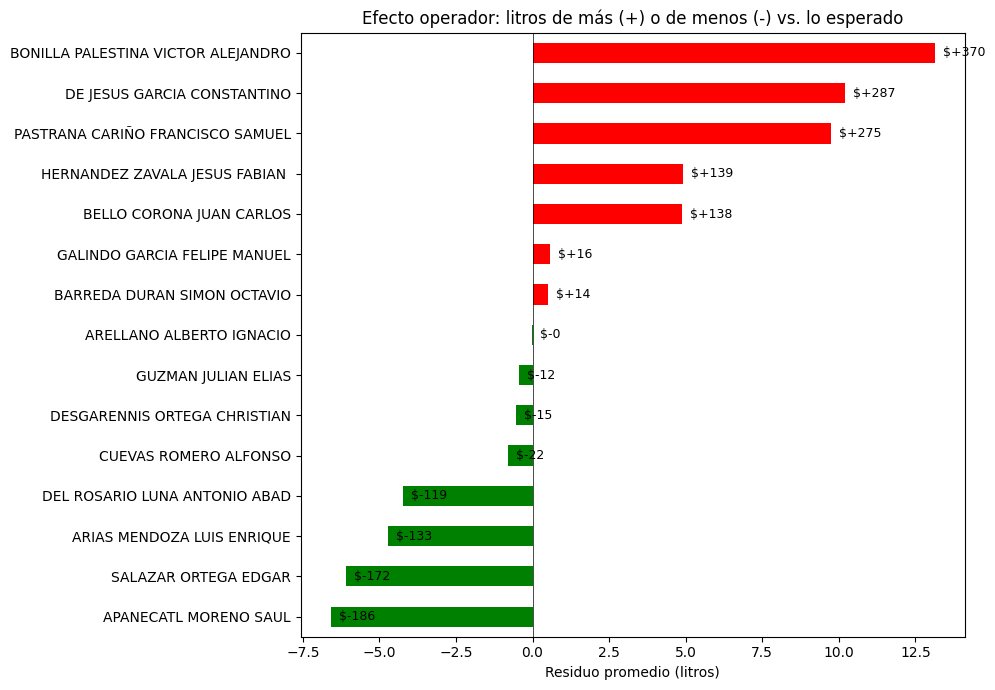

In [5]:
# Visualización: residuo promedio por operador
fig, ax = plt.subplots(figsize=(10, 7))
colores = ['green' if x < 0 else 'red' for x in residuo_por_operador['residuo_promedio']]
residuo_por_operador['residuo_promedio'].plot(kind='barh', color=colores, ax=ax)
ax.set_xlabel('Residuo promedio (litros)')
ax.set_ylabel('')
ax.set_title('Efecto operador: litros de más (+) o de menos (-) vs. lo esperado')
ax.axvline(x=0, color='black', linewidth=0.5)

# Agregar costo en pesos
for i, (idx, row) in enumerate(residuo_por_operador.iterrows()):
    costo = row['residuo_promedio'] * 28.20
    ax.text(row['residuo_promedio'], i, f'  ${costo:+.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Paso 3: Sistema de alertas — viajes que exceden +5% del consumo esperado

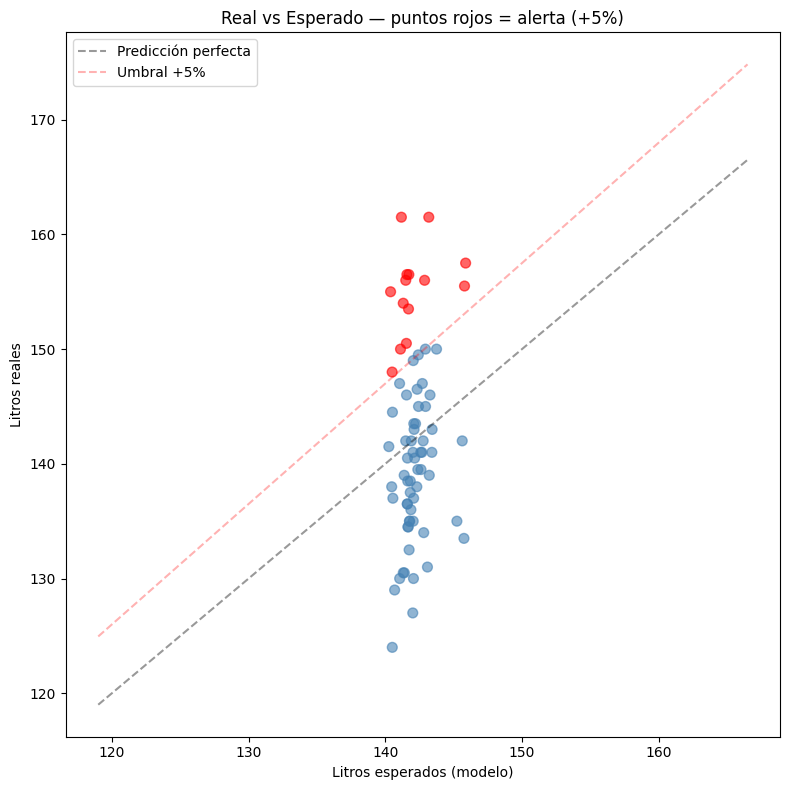

Viajes con alerta: 14 de 72 (19%)


In [6]:
# Marcar alertas
df_clean['alerta'] = df_clean['desviacion_pct'] > 5

# Scatter Real vs Esperado
fig, ax = plt.subplots(figsize=(8, 8))
colores = ['red' if a else 'steelblue' for a in df_clean['alerta']]
ax.scatter(df_clean['litros_esperados'], df_clean['Litros'], c=colores, alpha=0.6, s=50)

# Línea de predicción perfecta
lims = [df_clean['Litros'].min() - 5, df_clean['Litros'].max() + 5]
ax.plot(lims, lims, 'k--', alpha=0.4, label='Predicción perfecta')
ax.plot(lims, [l * 1.05 for l in lims], 'r--', alpha=0.3, label='Umbral +5%')

ax.set_xlabel('Litros esperados (modelo)')
ax.set_ylabel('Litros reales')
ax.set_title('Real vs Esperado — puntos rojos = alerta (+5%)')
ax.legend()
plt.tight_layout()
plt.show()

n_alertas = df_clean['alerta'].sum()
print(f"Viajes con alerta: {n_alertas} de {len(df_clean)} ({n_alertas/len(df_clean)*100:.0f}%)")

In [7]:
# Detalle de las alertas
alertas = df_clean[df_clean['alerta']][['Operador', 'km', 'Litros', 'litros_esperados', 'desviacion_pct']].copy()
alertas['litros_extra'] = alertas['Litros'] - alertas['litros_esperados']
alertas['costo_extra'] = alertas['litros_extra'] * 28.20
alertas = alertas.sort_values('desviacion_pct', ascending=False)
alertas.round(2)

,Operador,km,Litros,litros_esperados,desviacion_pct,litros_extra,costo_extra
18,ARELLANO ALBERTO IGNACIO,338.9,161.5,141.18,14.40,20.32,573.11
68,PASTRANA CARIÑO FRANCISCO SAMUEL,358.5,161.5,143.18,12.79,18.32,516.61
4,PASTRANA CARIÑO FRANCISCO SAMUEL,341.6,156.5,141.58,10.54,14.92,420.76
6,DE JESUS GARCIA CONSTANTINO,342.1,156.5,141.72,10.43,14.78,416.72
28,HERNANDEZ ZAVALA JESUS FABIAN,329.9,155.0,140.39,10.41,14.61,412.09
64,DE JESUS GARCIA CONSTANTINO,339.0,156.0,141.50,10.25,14.50,409.01
36,BONILLA PALESTINA VICTOR ALEJANDRO,353.0,156.0,142.87,9.19,13.13,370.13
46,BELLO CORONA JUAN CARLOS,343.3,154.0,141.31,8.98,12.69,357.77
62,PASTRANA CARIÑO FRANCISCO SAMUEL,342.2,153.5,141.70,8.33,11.80,332.85
5,GALINDO GARCIA FELIPE MANUEL,390.8,157.5,145.88,7.97,11.62,327.79


## Conclusiones del Modelado

**El modelo base (km + peso) tiene R² = -0.178** — las condiciones físicas del 
viaje no explican el consumo de combustible. Esto confirma que el factor 
dominante es el operador/unidad.

**El valor real del modelo está en los residuos:** la diferencia entre consumo 
real y esperado aísla el efecto del factor humano y permite generar alertas 
automáticas por viaje.

In [8]:
# ==============================
# CUANTIFICACIÓN ECONÓMICA
# ==============================

# Escenario 1: Si los 5 peores operadores alcanzan la mediana
mediana_residuo = residuo_por_operador['residuo_promedio'].median()
peores = residuo_por_operador[residuo_por_operador['residuo_promedio'] > 0]

ahorro_por_viaje = (peores['residuo_promedio'] - mediana_residuo) * 28.20
viajes_anuales_estimados = peores['viajes'] * (365 / 75)  # extrapolación simple

print("=== ESCENARIO: Si los operadores con residuo positivo alcanzan la mediana ===\n")
for op, row in peores.iterrows():
    ahorro = (row['residuo_promedio'] - mediana_residuo) * 28.20
    viajes_anio = row['viajes'] * (365 / 75)
    print(f"{op}: ahorro de ${ahorro:.0f}/viaje × {viajes_anio:.0f} viajes/año = ${ahorro * viajes_anio:,.0f}/año")

total_ahorro = sum(
    (row['residuo_promedio'] - mediana_residuo) * 28.20 * row['viajes'] * (365/75)
    for _, row in peores.iterrows()
)
print(f"\n AHORRO TOTAL ESTIMADO: ${total_ahorro:,.0f} MXN/año (solo esta ruta)")
print(f"   Con 1,000+ camiones en múltiples rutas, el impacto se multiplica.")

=== ESCENARIO: Si los operadores con residuo positivo alcanzan la mediana ===

BARREDA DURAN SIMON OCTAVIO: ahorro de $14/viaje × 5 viajes/año = $70/año
GALINDO GARCIA FELIPE MANUEL: ahorro de $17/viaje × 15 viajes/año = $243/año
BELLO CORONA JUAN CARLOS: ahorro de $138/viaje × 34 viajes/año = $4,699/año
HERNANDEZ ZAVALA JESUS FABIAN : ahorro de $139/viaje × 24 viajes/año = $3,378/año
PASTRANA CARIÑO FRANCISCO SAMUEL: ahorro de $275/viaje × 29 viajes/año = $8,040/año
DE JESUS GARCIA CONSTANTINO: ahorro de $288/viaje × 19 viajes/año = $5,597/año
BONILLA PALESTINA VICTOR ALEJANDRO: ahorro de $370/viaje × 5 viajes/año = $1,802/año

 AHORRO TOTAL ESTIMADO: $23,830 MXN/año (solo esta ruta)
   Con 1,000+ camiones en múltiples rutas, el impacto se multiplica.


In [9]:
# Escenario 2: Si TODOS alcanzan el nivel del percentil 75
p75_residuo = residuo_por_operador['residuo_promedio'].quantile(0.25)  # el Q1 porque están ordenados ascendente (más negativo = mejor)

print(f"=== ESCENARIO 2: Si todos rinden como el percentil 75 (residuo ≤ {p75_residuo:.2f} L) ===\n")

peores_p75 = residuo_por_operador[residuo_por_operador['residuo_promedio'] > p75_residuo]
total_p75 = 0
for op, row in peores_p75.iterrows():
    ahorro = (row['residuo_promedio'] - p75_residuo) * 28.20
    viajes_anio = row['viajes'] * (365/75)
    total_p75 += ahorro * viajes_anio
    print(f"{op}: ${ahorro:.0f}/viaje × {viajes_anio:.0f} viajes/año = ${ahorro * viajes_anio:,.0f}/año")

print(f"\n AHORRO TOTAL ESCENARIO 2: ${total_p75:,.0f} MXN/año (solo esta ruta)")

# Extrapolación conservadora a toda la flota
print(f"\n=== EXTRAPOLACIÓN A FLOTA COMPLETA ===")
print(f"Si este patrón aplica al 50% de las rutas de ORTA (1,000 camiones):")
print(f"  Escenario conservador: ${total_ahorro * 500 / 15:,.0f} MXN/año")
print(f"  Escenario optimista:   ${total_p75 * 500 / 15:,.0f} MXN/año")

=== ESCENARIO 2: Si todos rinden como el percentil 75 (residuo ≤ -2.51 L) ===

CUEVAS ROMERO ALFONSO: $48/viaje × 34 viajes/año = $1,643/año
DESGARENNIS ORTEGA CHRISTIAN: $56/viaje × 19 viajes/año = $1,088/año
GUZMAN JULIAN ELIAS: $59/viaje × 5 viajes/año = $286/año
ARELLANO ALBERTO IGNACIO: $71/viaje × 24 viajes/año = $1,716/año
BARREDA DURAN SIMON OCTAVIO: $85/viaje × 5 viajes/año = $414/año
GALINDO GARCIA FELIPE MANUEL: $87/viaje × 15 viajes/año = $1,273/año
BELLO CORONA JUAN CARLOS: $208/viaje × 34 viajes/año = $7,102/año
HERNANDEZ ZAVALA JESUS FABIAN : $209/viaje × 24 viajes/año = $5,094/año
PASTRANA CARIÑO FRANCISCO SAMUEL: $346/viaje × 29 viajes/año = $10,100/año
DE JESUS GARCIA CONSTANTINO: $358/viaje × 19 viajes/año = $6,970/año
BONILLA PALESTINA VICTOR ALEJANDRO: $441/viaje × 5 viajes/año = $2,145/año

 AHORRO TOTAL ESCENARIO 2: $37,830 MXN/año (solo esta ruta)

=== EXTRAPOLACIÓN A FLOTA COMPLETA ===
Si este patrón aplica al 50% de las rutas de ORTA (1,000 camiones):
  Escena

## Resumen 

### El problema
El combustible representa ~30% de los costos operativos de ORTA. Existe 
variabilidad inexplicable en el consumo entre viajes con condiciones similares.

### Lo que encontramos
1. **Las condiciones del viaje no explican el consumo.** Peso, distancia, hora 
   de salida, duración y día de la semana tienen correlación débil o nula con 
   el rendimiento. El modelo base (km + peso) tiene R² = -0.178.

2. **El factor dominante es el operador/unidad.** La diferencia entre el mejor 
   y peor operador es de $556/viaje. Los residuos del modelo aíslan este efecto.

3. **19% de los viajes generan alerta** (consumo >5% sobre lo esperado), 
   concentrados en operadores específicos.

### Cuantificación económica
| Escenario | Ahorro/año (ruta) | Ahorro/año (flota estimado) |
|-----------|------------------|-----------------------------|
| Conservador (alcanzar mediana) | $23,830 | $794,342 |
| Optimista (alcanzar P75) | $37,830 | $1,261,015 |

### Recomendaciones a ORTA
1. **Capacitación diferenciada** usando el cuadrante de eficiencia vs consistencia
2. **Sistema de alertas** por viaje (+5% del consumo esperado)
3. **Rotación operador-unidad** para separar efecto conductor vs camión
4. **Programa de incentivos** basado en el scoring de residuos